# MarketPulse — Churn Prediction Model

Predicts which customers are likely to churn (not return), using RFM and behavioral features engineered in the ETL step. Compares Logistic Regression, Random Forest, and XGBoost, and uses SHAP to interpret which features drive predictions.

**Churn definition:** since this dataset has no explicit "cancelled subscription" signal (it's a marketplace, not a subscription service), churn is defined behaviorally: a customer is "churned" if they have not purchased again within 180 days of their last order, relative to the dataset's most recent date. This is a reasonable, explicit proxy — documented here rather than left ambiguous.

## 1. Setup — Load and Prepare Features

In [0]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

customer_features_pd = spark.sql("SELECT * FROM marketpulse_customer_features").toPandas()

# Churn label: no purchase in the 180 days before the dataset's most recent date
# recency_days already measures days since last purchase relative to max order date
customer_features_pd["churned"] = (customer_features_pd["recency_days"] > 180).astype(int)

print(f"Total customers: {customer_features_pd.shape[0]}")
print(customer_features_pd["churned"].value_counts(normalize=True))

Total customers: 93345
churned
1    0.590487
0    0.409513
Name: proportion, dtype: float64


## 2. Feature Selection and Train/Test Split

In [0]:
feature_cols = ["frequency", "monetary_value", "avg_order_value", "avg_delivery_days", "distinct_categories"]

model_data = customer_features_pd.dropna(subset=feature_cols)
print(f"Rows after dropping missing feature values: {model_data.shape[0]}")

X = model_data[feature_cols]
y = model_data["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Rows after dropping missing feature values: 93336
Train: 74668, Test: 18668


## 3. Train and Evaluate Models

Three models compared: Logistic Regression (simple, interpretable baseline), Random Forest, and XGBoost (both handle non-linear patterns better). Since churn is imbalanced, precision, recall, F1, and ROC-AUC are reported — not accuracy alone, which would be misleading on imbalanced data.

In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=200),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

results = []

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.684449  0.465530  0.554152  0.611903
1        Random Forest   0.704565  0.733581  0.718781  0.710027
2              XGBoost   0.656570  0.814042  0.726875  0.662928


## 4. SHAP Interpretation — Which Features Drive Churn Predictions?

Random Forest is selected as the primary model (best ROC-AUC, indicating the strongest overall class separation), though XGBoost remains a reasonable alternative if recall is prioritized over precision. SHAP values explain which features push individual predictions toward "churned" vs. "active," and reveal the model's overall feature importance in a way that raw feature_importances_ cannot — SHAP shows both magnitude and direction of each feature's effect.

In [0]:
%pip install shap

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import shap
import matplotlib.pyplot as plt

rf_model = models["Random Forest"]

explainer = shap.TreeExplainer(rf_model)

# Sample for speed — SHAP summary plots don't need the full test set,
# a representative sample shows the same pattern much faster.
# check_additivity=False: skips a slow internal consistency check,
# does not affect the SHAP values themselves.
X_test_sample = X_test.sample(n=200, random_state=42)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)


In [0]:
print(f"Type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List of {len(shap_values)} arrays, each shaped: {shap_values[0].shape}")
else:
    print(f"Array shape: {shap_values.shape}")

Type: <class 'numpy.ndarray'>
Array shape: (200, 5, 2)


Corrected shape: (200, 5)


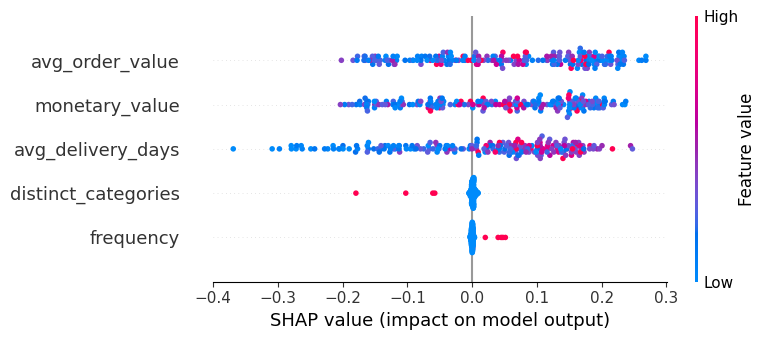

In [0]:
shap_values_churn = shap_values[:, :, 1]
print(f"Corrected shape: {shap_values_churn.shape}")

shap.summary_plot(shap_values_churn, X_test_sample, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.show()

## Summary

Three churn prediction models were trained on RFM and behavioral features (frequency, monetary_value, avg_order_value, avg_delivery_days, distinct_categories), with churn defined as no purchase within 180 days of last order.

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | 0.684 | 0.466 | 0.554 | 0.612 |
| Random Forest | 0.705 | 0.734 | 0.719 | 0.710 |
| XGBoost | 0.657 | 0.814 | 0.727 | 0.663 |

**Random Forest selected as primary model** (best ROC-AUC, indicating strongest overall class separation). XGBoost remains a reasonable alternative if recall is prioritized over precision.

**SHAP interpretation:** avg_order_value and monetary_value are the strongest predictors, both associated with higher churn risk when high. avg_delivery_days shows a weak signal not detected in the earlier standalone correlation test, suggesting a multivariate effect. distinct_categories and frequency show comparatively little individual signal. Multicollinearity between monetary_value and avg_order_value is a noted limitation on interpreting their SHAP contributions as fully independent.

**Bug fixed during this phase:** a SHAP array-indexing mismatch (3D array vs. expected list format) — caught by checking the array shape explicitly rather than trusting the plot output at face value.